In [4]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load dataset
data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Step 3: Explore basic info
print("Shape of data:", data.shape)
display(data.head())
data.info()

# Step 4: Check for missing values
print("\nMissing values per column:")
print(data.isnull().sum())

# Step 5: View column names
print("\nColumn names:")
print(data.columns.tolist())


Shape of data: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


C:\Users\Admin\AppData\Local\Temp\ipykernel_23336\2044426717.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=data, palette='coolwarm')


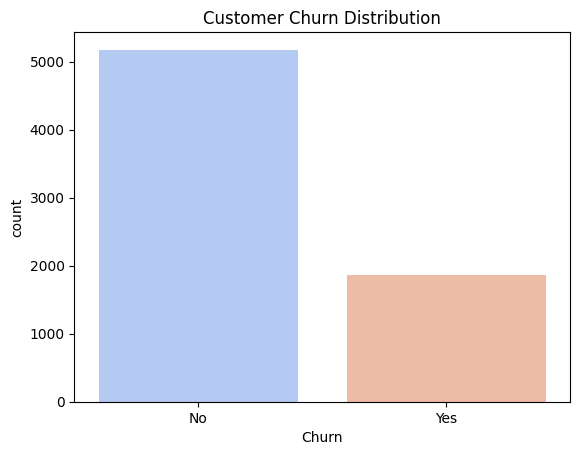

In [3]:
# Visualize churn distribution
sns.countplot(x='Churn', data=data, palette='coolwarm')
plt.title("Customer Churn Distribution")
plt.show()


In [5]:
print("Missing values per column:\n", data.isnull().sum())

data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data = data.dropna()

print("\nAfter cleaning, shape of data:", data.shape)


Missing values per column:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

After cleaning, shape of data: (7032, 21)


In [6]:
data = data.drop(['customerID'], axis=1)


In [7]:
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})



In [8]:
data = pd.get_dummies(data, drop_first=True)
print("After encoding, data shape:", data.shape)


After encoding, data shape: (7032, 31)


In [3]:
from sklearn.model_selection import train_test_split

X = data.drop('Churn', axis=1)
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


NameError: name 'data' is not defined

✅ Model Accuracy: 78.54%

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



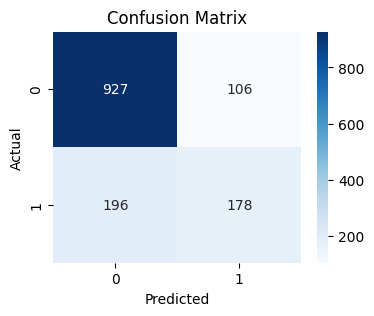

In [9]:
# Step 1: Import the model and evaluation tools
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 2: Initialize the Random Forest model
model = RandomForestClassifier(random_state=42)

# Step 3: Train (fit) the model using the training data
model.fit(X_train, y_train)

# Step 4: Make predictions on the test data
y_pred = model.predict(X_test)

# Step 5: Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Model Accuracy: {accuracy*100:.2f}%")

# Step 6: Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Step 7: Confusion Matrix (visual)
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Before SMOTE: Churn
0    4130
1    1495
Name: count, dtype: int64
After SMOTE: Churn
1    4130
0    4130
Name: count, dtype: int64

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.59      0.58       374

    accuracy                           0.78      1407
   macro avg       0.71      0.71      0.71      1407
weighted avg       0.78      0.78      0.78      1407



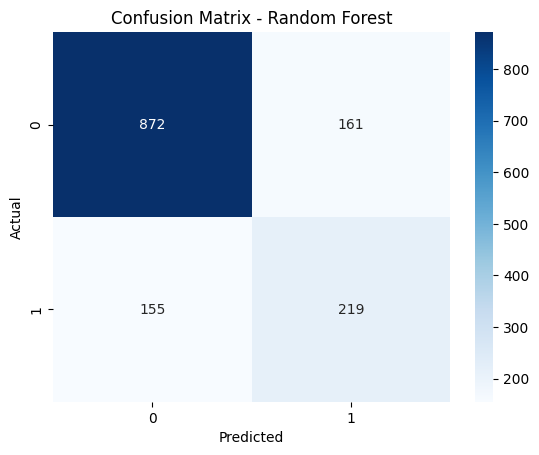

In [11]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Separate features and target
X = data.drop('Churn', axis=1)
y = data['Churn']

# Split the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE (balances classes by creating synthetic samples)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

# Train a Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)

# Predictions
y_pred = rf.predict(X_test)

# Evaluation
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix visualization
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_23336\1425518791.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


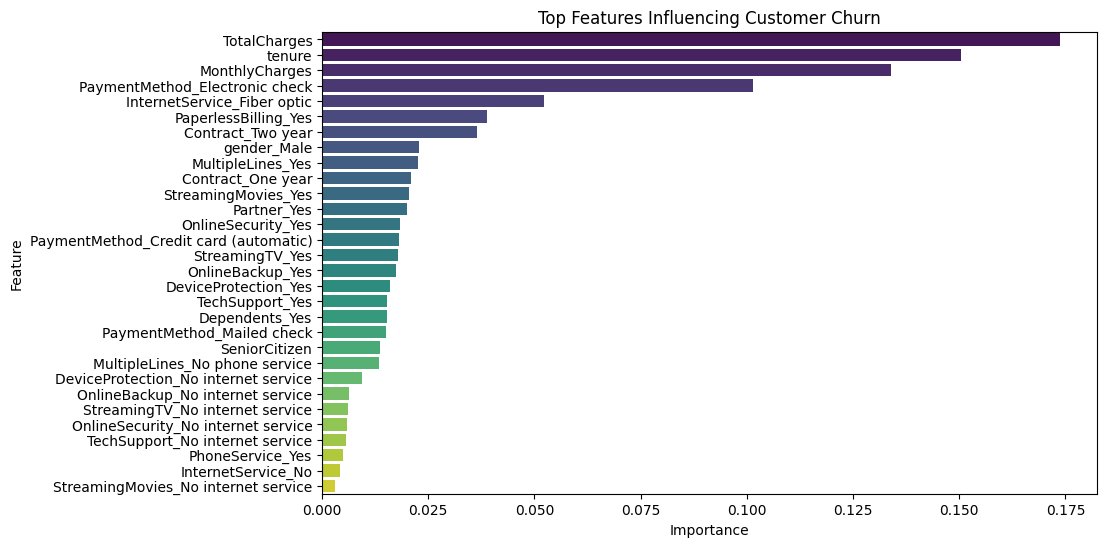

In [12]:
# Feature Importance Visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importance from the model
importance = rf.feature_importances_

# Combine with feature names
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Top Features Influencing Customer Churn')
plt.show()


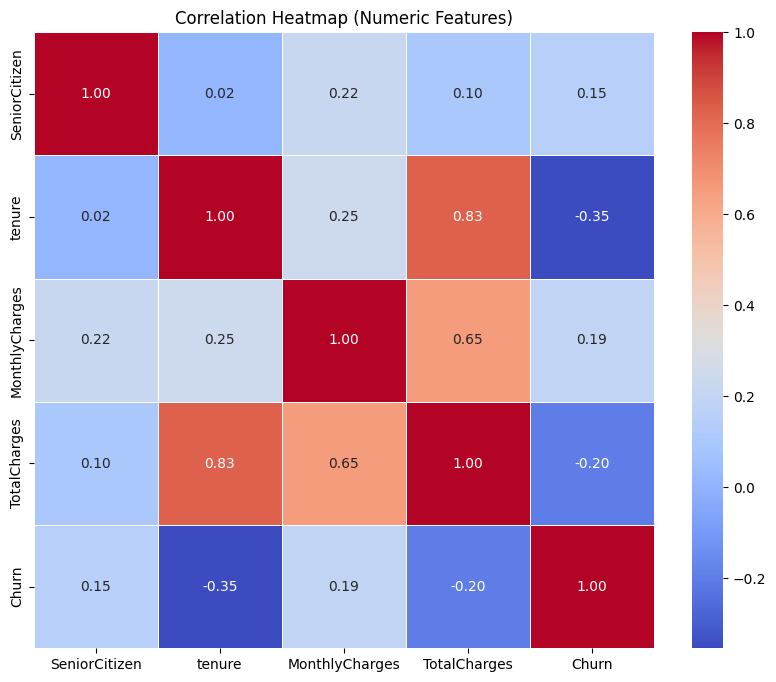

In [13]:
# Correlation Heatmap (only for numeric features)
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_data = data.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


ValueError: Could not interpret value `gender` for `x`. An entry with this name does not appear in `data`.

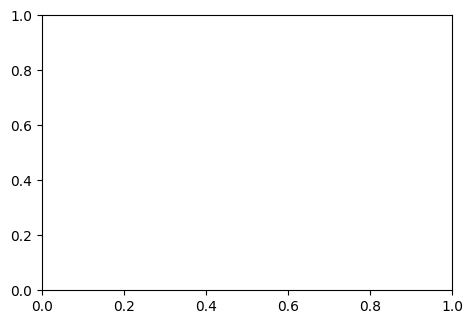

In [14]:
# Visualize churn rate across key categorical features
categorical_features = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

plt.figure(figsize=(18, 25))
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(6, 3, i)
    sns.countplot(x=feature, hue='Churn', data=data, palette='coolwarm')
    plt.title(f'Churn by {feature}')
    plt.xlabel('')
    plt.ylabel('')
    plt.tight_layout()
plt.show()


In [15]:
print(data.columns.tolist())



['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


C:\Users\Admin\AppData\Local\Temp\ipykernel_23336\2919734274.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Churn', y=feature, data=data, palette='coolwarm')
C:\Users\Admin\AppData\Local\Temp\ipykernel_23336\2919734274.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Churn', y=feature, data=data, palette='coolwarm')
C:\Users\Admin\AppData\Local\Temp\ipykernel_23336\2919734274.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Churn', y=feature, data=data, palette='coolwarm')
C:\Users\Admin\AppData\Local\Temp\ipykernel_23

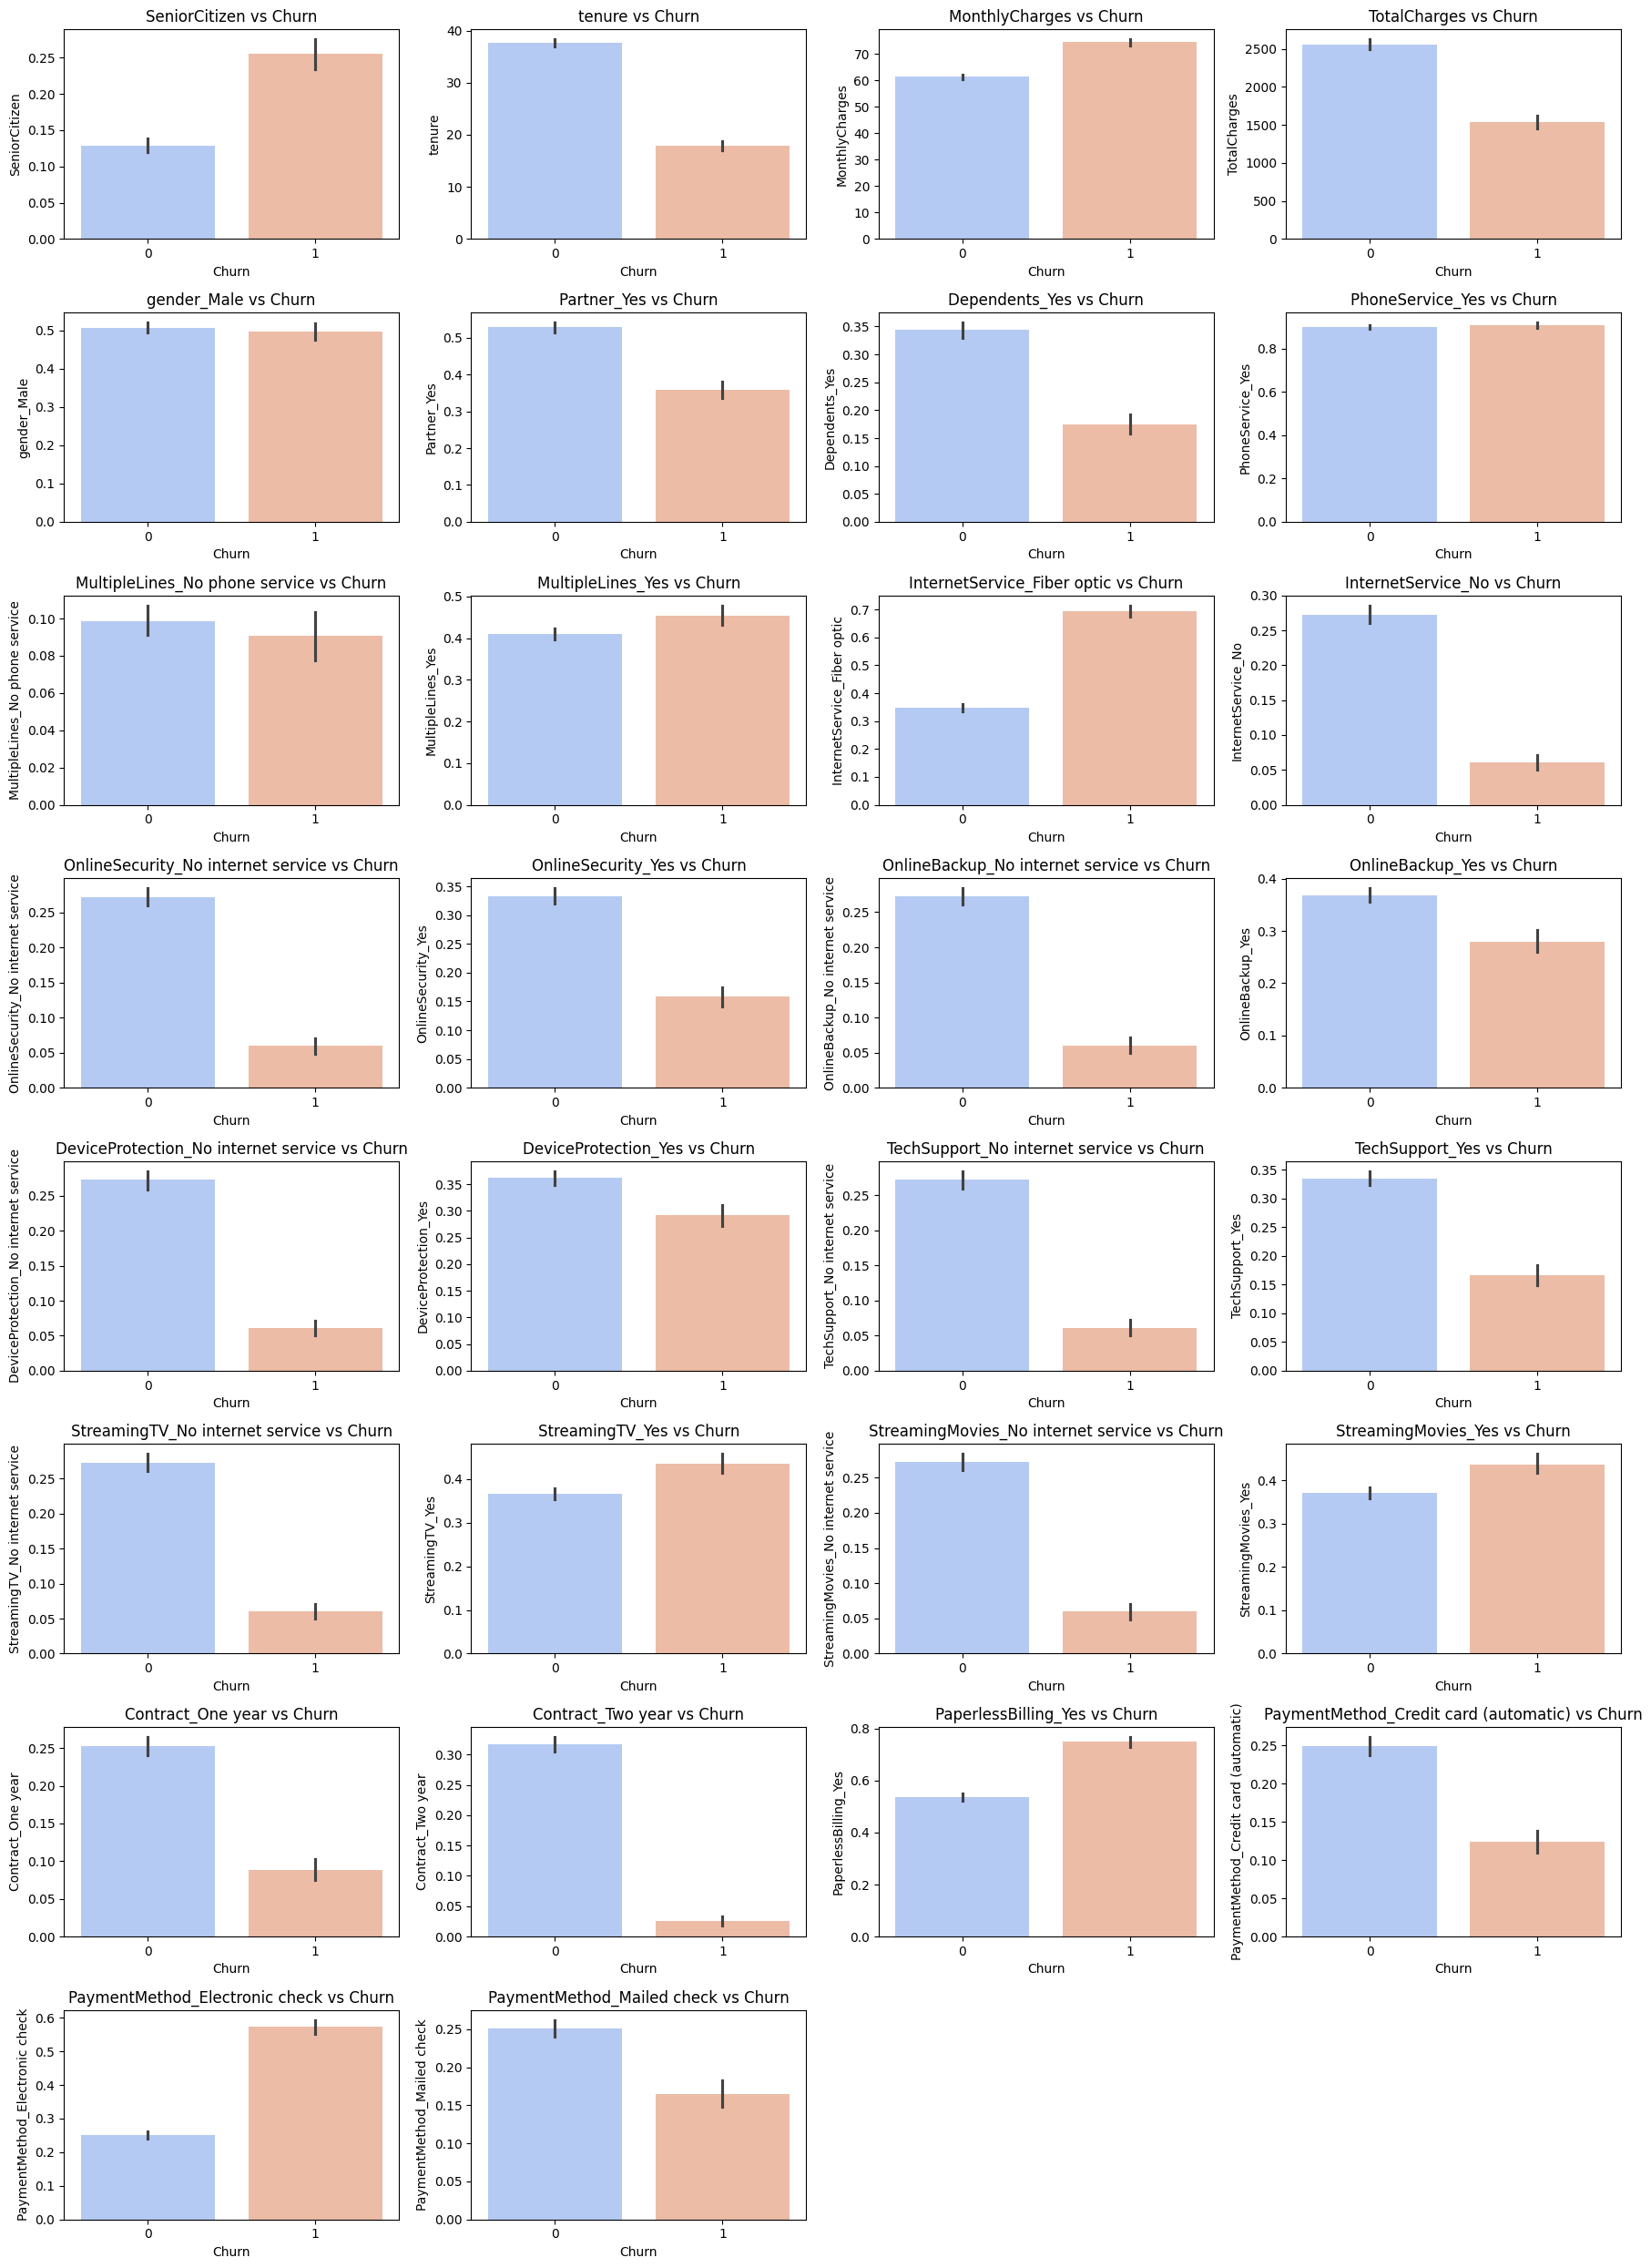

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select all features except the target
features = [col for col in data.columns if col != 'Churn']

plt.figure(figsize=(18, 25))
for i, feature in enumerate(features, 1):
    plt.subplot(8, 4, i)
    sns.barplot(x='Churn', y=feature, data=data, palette='coolwarm')
    plt.title(f'{feature} vs Churn')
    plt.tight_layout()
plt.show()


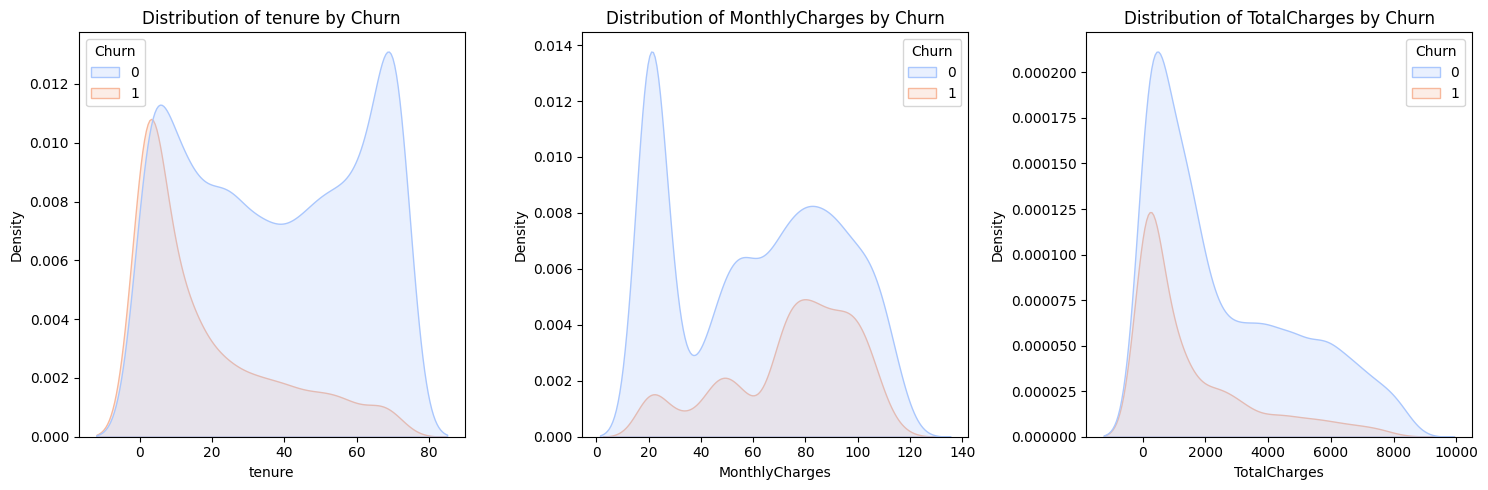

In [17]:
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(15, 5))
for i, feature in enumerate(numeric_features, 1):
    plt.subplot(1, 3, i)
    sns.kdeplot(data=data, x=feature, hue='Churn', fill=True, palette='coolwarm')
    plt.title(f'Distribution of {feature} by Churn')
    plt.xlabel(feature)
    plt.ylabel('Density')
plt.tight_layout()
plt.show()


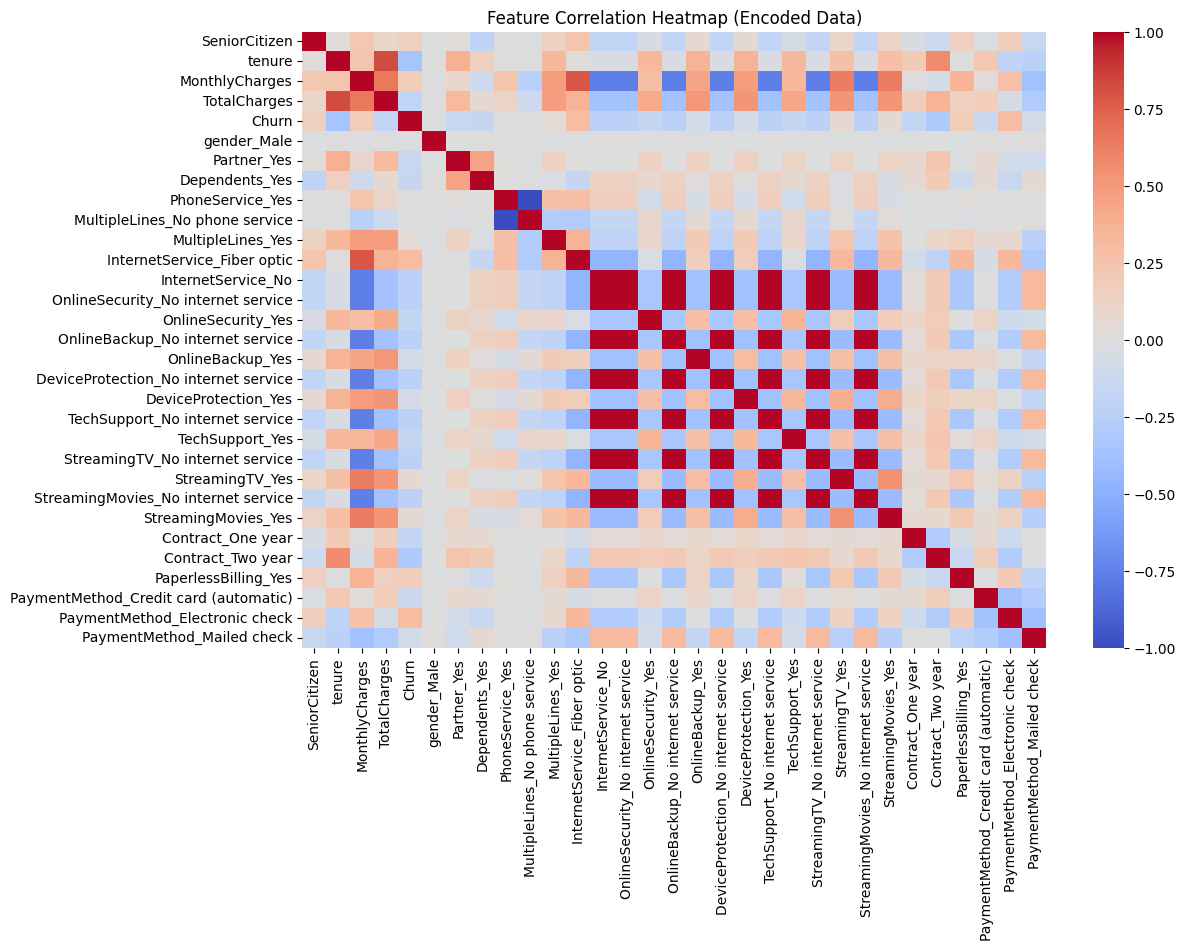

In [18]:
plt.figure(figsize=(12, 8))
corr = data.corr()
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap (Encoded Data)")
plt.show()


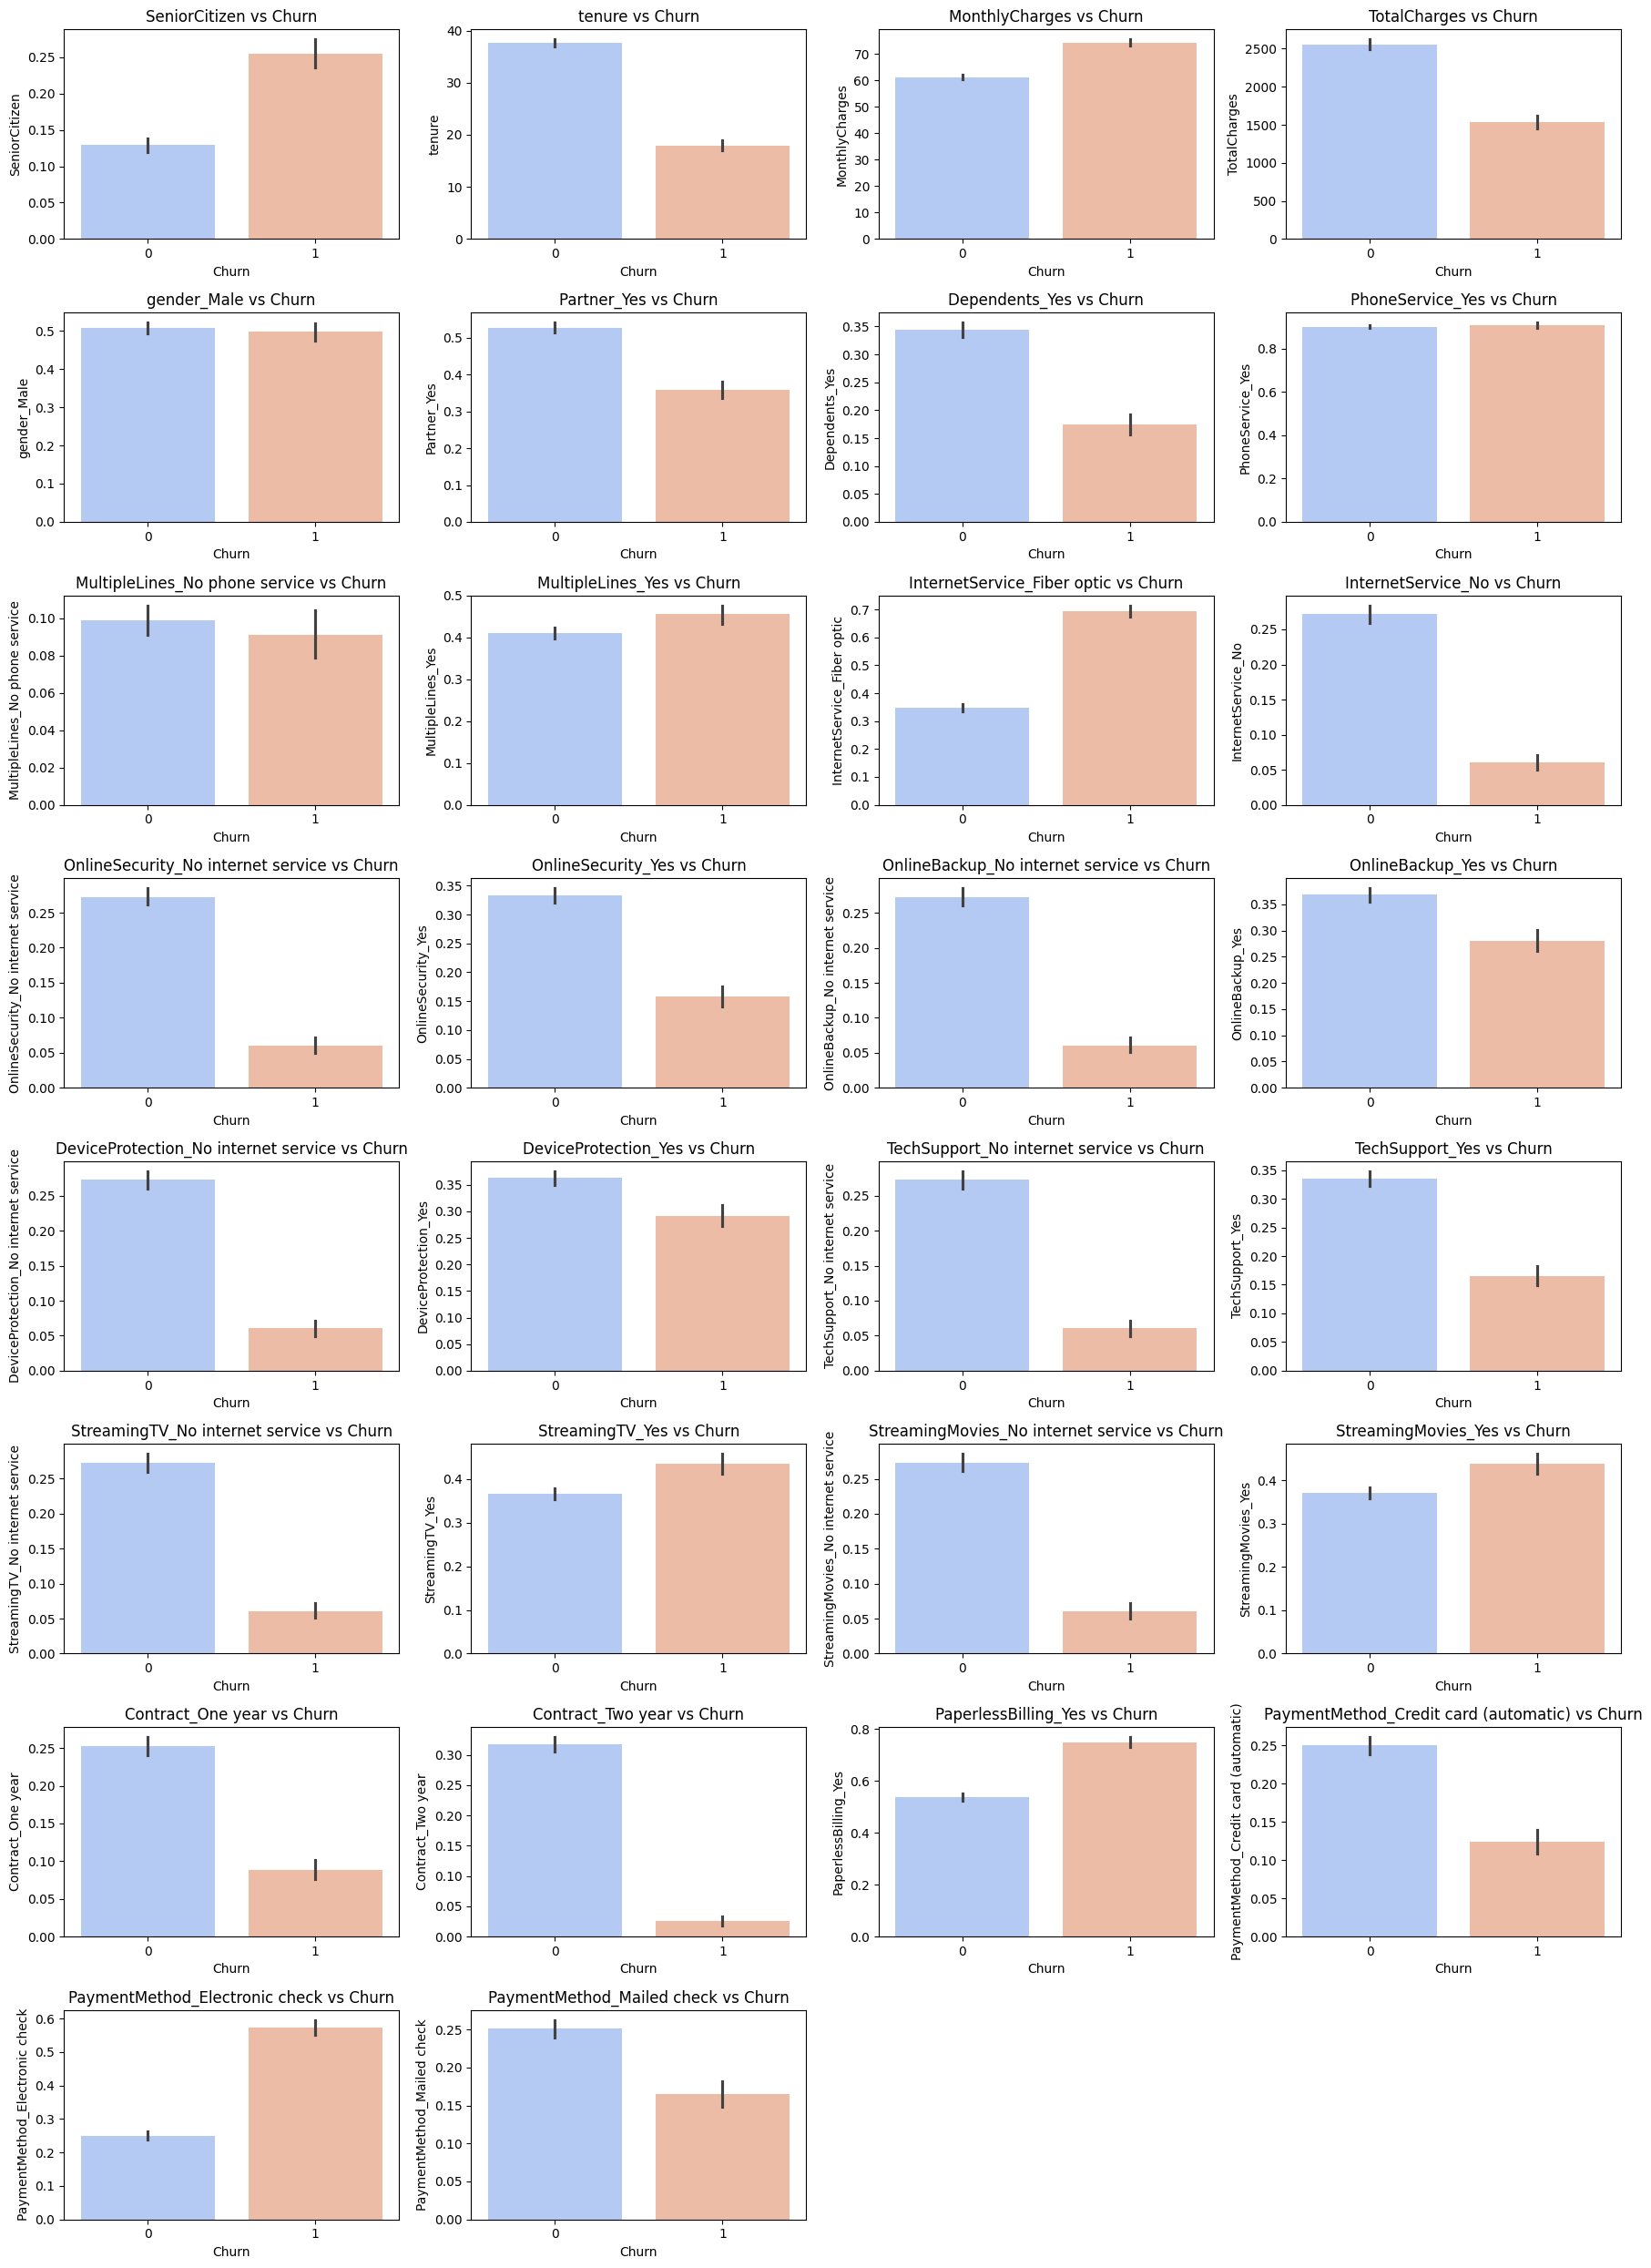

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

features = [col for col in data.columns if col != 'Churn']

plt.figure(figsize=(18, 25))
for i, feature in enumerate(features, 1):
    plt.subplot(8, 4, i)
    sns.barplot(x='Churn', y=feature, hue='Churn', data=data, palette='coolwarm', legend=False)
    plt.title(f'{feature} vs Churn')
    plt.tight_layout()
plt.show()


In [20]:
import numpy as np
import pandas as pd

def predict_churn(input_data):
    # input_data should be a dictionary matching your dataset's features
    input_df = pd.DataFrame([input_data])

    # Ensure all required columns are present (missing ones set to 0)
    for col in X.columns:
        if col not in input_df.columns:
            input_df[col] = 0

    # Align columns in the same order as training data
    input_df = input_df[X.columns]

    # Predict
    prediction = rf.predict(input_df)[0]
    probability = rf.predict_proba(input_df)[0][1]

    if prediction == 1:
        print(f"⚠️ The model predicts the customer is likely to CHURN (probability: {probability:.2f})")
    else:
        print(f"✅ The model predicts the customer will STAY (probability: {1 - probability:.2f})")


In [21]:
sample_customer = {
    'SeniorCitizen': 0,
    'tenure': 5,
    'MonthlyCharges': 85.0,
    'TotalCharges': 400.0,
    'gender_Male': 1,
    'Partner_Yes': 0,
    'Dependents_Yes': 0,
    'PhoneService_Yes': 1,
    'MultipleLines_No phone service': 0,
    'MultipleLines_Yes': 1,
    'InternetService_Fiber optic': 1,
    'InternetService_No': 0,
    'OnlineSecurity_No internet service': 0,
    'OnlineSecurity_Yes': 0,
    'OnlineBackup_No internet service': 0,
    'OnlineBackup_Yes': 1,
    'DeviceProtection_No internet service': 0,
    'DeviceProtection_Yes': 1,
    'TechSupport_No internet service': 0,
    'TechSupport_Yes': 0,
    'StreamingTV_No internet service': 0,
    'StreamingTV_Yes': 1,
    'StreamingMovies_No internet service': 0,
    'StreamingMovies_Yes': 1,
    'Contract_One year': 0,
    'Contract_Two year': 0,
    'PaperlessBilling_Yes': 1,
    'PaymentMethod_Credit card (automatic)': 0,
    'PaymentMethod_Electronic check': 1,
    'PaymentMethod_Mailed check': 0
}

predict_churn(sample_customer)


⚠️ The model predicts the customer is likely to CHURN (probability: 1.00)


In [9]:
!pip install shap


In [24]:
import shap

# Use the modern SHAP explainer
explainer = shap.Explainer(model, X_train)

# Compute SHAP values for the test set
shap_values = explainer(X_test)

# Pick a single sample to explain
sample_index = 0
sample_data = X_test.iloc[[sample_index]]

# Show model prediction
prediction = model.predict(sample_data)[0]
prob = model.predict_proba(sample_data)[0][1]
print(f"🔍 Predicted Churn: {prediction} (probability: {prob:.2f})")

# Force plot for that single sample
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values.values[sample_index], sample_data)


TypeError: Cannot cast array data from dtype('O') to dtype('float64') according to the rule 'safe'

In [25]:
# Convert numeric columns to float
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')  # convert invalid to NaN

# Fill missing values if any
data[numeric_cols] = data[numeric_cols].fillna(0)


In [26]:
X_train_numeric = X_train.astype(float)
X_test_numeric = X_test.astype(float)


In [27]:
import shap

# Initialize SHAP for Random Forest
explainer = shap.TreeExplainer(rf)  # rf = your trained RandomForestClassifier
shap_values = explainer.shap_values(X_test_numeric)

# Pick a single customer
sample_index = 0
sample_data = X_test_numeric.iloc[[sample_index]]

# Force plot (individual prediction explanation)
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[1][sample_index], sample_data)


DimensionError: Length of features is not equal to the length of shap_values!

In [28]:
X_train_numeric = X_train.astype(float)
X_test_numeric = X_test.astype(float)


In [29]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_test_numeric)  # modern SHAP API


In [30]:
# Pick a single customer
sample_index = 0

shap.plots.waterfall(shap_values[sample_index])


ValueError: The waterfall plot can currently only plot a single explanation, but a matrix of explanations (shape (30, 2)) was passed! Perhaps try `shap.plots.waterfall(shap_values[0])` or for multi-output models, try `shap.plots.waterfall(shap_values[0, 0])`.

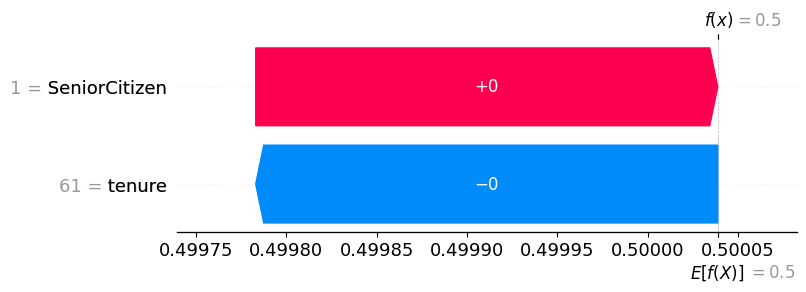

In [31]:
import shap

# Ensure features are numeric
X_train_numeric = X_train.astype(float)
X_test_numeric = X_test.astype(float)

# Create explainer
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_numeric)  # returns a list: [class 0, class 1]

# Pick a single sample
sample_index = 0

# Use class 1 (churn) SHAP values
shap.plots.waterfall(shap.Explanation(
    values=shap_values[1][sample_index],       # class 1 SHAP values
    base_values=explainer.expected_value[1],  # base value for class 1
    data=X_test_numeric.iloc[sample_index]    # feature values
))


In [32]:
shap.summary_plot(shap_values[1], X_test_numeric)



AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

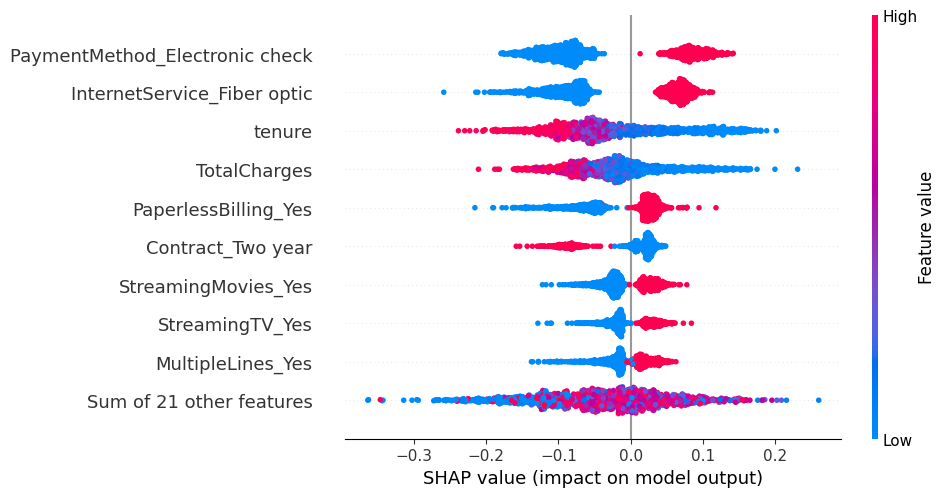

In [33]:
import shap

# Ensure all numeric
X_train_numeric = X_train.astype(float)
X_test_numeric = X_test.astype(float)

# Explainer
explainer = shap.TreeExplainer(rf)

# Explain the test set
shap_values = explainer(X_test_numeric)  # returns a modern Explanation object

# Global feature importance
shap.plots.beeswarm(shap_values[:, :, 1])  # class 1 (churn)


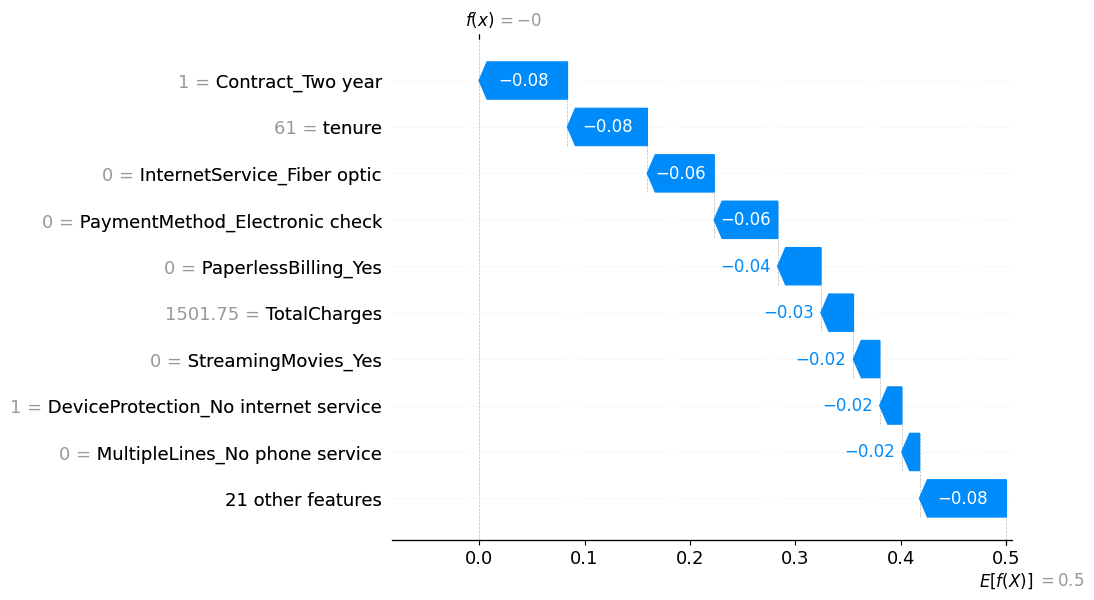

In [34]:
sample_index = 0
shap.plots.waterfall(shap_values[sample_index, :, 1])


In [1]:
import joblib

# Replace "model" with your trained model variable
joblib.dump(model, "model.pkl")
print("✅ Model saved successfully!")



NameError: name 'model' is not defined

In [2]:
import joblib

# Save the trained model
joblib.dump(model, "model.pkl")

# Save your training data for SHAP global interpretation
joblib.dump(X_train, "X_train.pkl")

# (Optional) If you used a scaler or encoder, save them too
# joblib.dump(scaler, "scaler.pkl")
# joblib.dump(encoder, "encoder.pkl")

print("✅ Model and files saved successfully!")


NameError: name 'model' is not defined